In [1]:
# Re-run after reset
import numpy as np
import pandas as pd
from sklearn.isotonic import IsotonicRegression
from scipy.stats import spearmanr
import matplotlib.pyplot as plt


def generate_data(n=200, noise=0.1, seed=42):
    np.random.seed(seed)
    x = np.sort(np.random.rand(n))
    y = np.sin(4 * x) + noise * np.random.randn(n)
    return x, y


def relaxed_pava(x, y, epsilon=0.05):
    n = len(y)
    y_fit = y.copy()
    i = 0
    while i < n - 1:
        if y_fit[i] > y_fit[i + 1] + epsilon:
            j = i
            while j >= 0 and y_fit[j] > y_fit[j + 1] + epsilon:
                avg = (y_fit[j] + y_fit[j + 1]) / 2
                y_fit[j] = y_fit[j + 1] = avg
                j -= 1
            i = max(j + 1, 0)
        else:
            i += 1
    return y_fit


def nearly_isotonic(x, y, lam=1.0):
    n = len(y)
    beta = y.copy()
    groups = [[i] for i in range(n)]

    def compute_collisions():
        collisions = []
        for i in range(len(groups) - 1):
            g1 = groups[i]
            g2 = groups[i + 1]
            i1 = g1[0]
            i2 = g2[0]
            if beta[i1] > beta[i2]:
                collisions.append((i, abs(beta[i1] - beta[i2]) / 2))
            else:
                collisions.append((i, np.inf))
        return collisions

    lam_curr = 0
    while True:
        collisions = compute_collisions()
        if all(t[1] > lam for t in collisions):
            break
        # find minimum collision time
        idx, t_min = min(collisions, key=lambda x: x[1])
        lam_curr += t_min
        # merge groups
        new_group = groups[idx] + groups[idx + 1]
        avg = np.mean([beta[i] for i in new_group])
        for i in new_group:
            beta[i] = avg
        groups = groups[:idx] + [new_group] + groups[idx + 2:]

    return beta


def binned_calibration_error(y_true, y_pred, bins=10):
    df = pd.DataFrame({'y_true': y_true, 'y_pred': y_pred})
    df['bin'] = pd.qcut(df['y_pred'], q=bins, duplicates='drop')
    grouped = df.groupby('bin').mean()
    return np.mean(np.abs(grouped['y_true'] - grouped['y_pred']))


def analyze_fit(x, y, y_fit, method_name):
    return {
        'method': method_name,
        'binned_calibration_error': binned_calibration_error(y, y_fit),
        'n_unique_fit': len(np.unique(y_fit)),
        'n_unique_orig': len(np.unique(y)),
        'spearman_y': spearmanr(y, y_fit).correlation,
        'spearman_x': spearmanr(x, y_fit).correlation,
    }


# Generate data
x, y = generate_data()

# Fit standard isotonic regression
iso = IsotonicRegression(increasing=True)
y_iso = iso.fit_transform(x, y)

# Fit relaxed PAVA
y_relaxed = relaxed_pava(x, y, epsilon=0.05)

# Fit nearly-isotonic
y_near_iso = nearly_isotonic(x, y, lam=0.1)

# Analyze all
results = [
    analyze_fit(x, y, y_iso, 'Isotonic'),
    analyze_fit(x, y, y_relaxed, 'Relaxed PAVA'),
    analyze_fit(x, y, y_near_iso, 'Nearly-Isotonic')
]

results_df = pd.DataFrame(results)

/var/folders/2p/6m62flgx7677h842nfsgzgvh0000gn/T/ipykernel_40654/2196118768.py:72: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('bin').mean()
/var/folders/2p/6m62flgx7677h842nfsgzgvh0000gn/T/ipykernel_40654/2196118768.py:72: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('bin').mean()
/var/folders/2p/6m62flgx7677h842nfsgzgvh0000gn/T/ipykernel_40654/2196118768.py:72: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future def

In [2]:
results_df

,method,binned_calibration_error,n_unique_fit,n_unique_orig,spearman_y,spearman_x
0,Isotonic,1.110223e-16,9,200,0.223096,0.543097
1,Relaxed PAVA,9.162028e-03,152,200,0.979959,-0.482502
2,Nearly-Isotonic,3.469447e-17,92,200,0.989910,-0.480928


In [4]:
import numpy as np
import pandas as pd
from sklearn.isotonic import IsotonicRegression
from scipy.stats import binned_statistic, spearmanr
import cvxpy as cp
import matplotlib.pyplot as plt

# Simulate data
np.random.seed(42)
x = np.sort(np.random.rand(100))
y_true = 1 / (1 + np.exp(-4 * (x - 0.5)))  # true underlying probability function
y = y_true + np.random.normal(0, 0.1, size=len(x))  # add noise

# 1. Isotonic Regression
iso = IsotonicRegression(out_of_bounds="clip")
y_iso = iso.fit_transform(x, y)

# 2. Nearly-Isotonic Regression via cvxpy
def nearly_isotonic_regression(x, y, lam=1.0):
    n = len(y)
    beta = cp.Variable(n)
    obj = cp.Minimize(cp.sum_squares(beta - y) + lam * cp.norm1(beta[1:] - beta[:-1]))
    constraints = [beta[1:] >= beta[:-1]]
    prob = cp.Problem(obj, constraints)
    prob.solve()
    return beta.value

y_near_iso = nearly_isotonic_regression(x, y, lam=1.0)

# Calibration error
def binned_calibration_error(x, y_true, y_pred, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    bin_ids = np.digitize(x, bins) - 1
    error = 0
    for i in range(n_bins):
        bin_mask = bin_ids == i
        if np.any(bin_mask):
            avg_pred = np.mean(y_pred[bin_mask])
            avg_true = np.mean(y_true[bin_mask])
            error += (avg_pred - avg_true) ** 2
    return np.sqrt(error / n_bins)

# Compute metrics
def compute_metrics(x, y_true, y_fit, name):
    return {
        "method": name,
        "binned_calibration_error": binned_calibration_error(x, y_true, y_fit),
        "n_unique_y_fit": len(np.unique(np.round(y_fit, 6))),
        "n_unique_y_true": len(np.unique(np.round(y_true, 6))),
        "spearman_corr_to_y_true": spearmanr(y_true, y_fit).correlation,
        "spearman_corr_to_y": spearmanr(y, y_fit).correlation,
    }

metrics = [
    compute_metrics(x, y_true, y, "Raw y"),
    compute_metrics(x, y_true, y_iso, "Isotonic"),
    compute_metrics(x, y_true, y_near_iso, "Nearly-Isotonic (cvxpy)")
]

df_metrics = pd.DataFrame(metrics)

In [5]:
df_metrics

,method,binned_calibration_error,n_unique_y_fit,n_unique_y_true,spearman_corr_to_y_true,spearman_corr_to_y
0,Raw y,0.019968,100,100,0.941314,1.000000
1,Isotonic,0.017885,25,100,0.998069,0.952809
2,Nearly-Isotonic (cvxpy),0.018582,56,100,0.993363,0.951875


In [65]:
import numpy as np
import cvxpy as cp
from scipy.stats import spearmanr

def nearly_isotonic(x, y, lam=1.0):
    """
    Implementation of nearly isotonic regression using a merge algorithm.
    """
    n = len(y)
    beta = y.copy()
    groups = [[i] for i in range(n)]
    
    def compute_collisions():
        collisions = []
        for i in range(len(groups) - 1):
            g1 = groups[i]
            g2 = groups[i + 1]
            i1 = g1[0]
            i2 = g2[0]
            if beta[i1] > beta[i2]:
                collisions.append((i, abs(beta[i1] - beta[i2]) / 2))
            else:
                collisions.append((i, np.inf))
        return collisions
    
    lam_curr = 0
    while True:
        collisions = compute_collisions()
        if all(t[1] > lam for t in collisions):
            break
        
        # find minimum collision time
        idx, t_min = min(collisions, key=lambda x: x[1])
        lam_curr += t_min
        
        # Check if we've exceeded lambda
        if lam_curr > lam:
            break
            
        # merge groups
        new_group = groups[idx] + groups[idx + 1]
        avg = np.mean([beta[i] for i in new_group])
        for i in new_group:
            beta[i] = avg
        groups = groups[:idx] + [new_group] + groups[idx + 2:]
    
    return beta

def nearly_isotonic(x, y, lam=1.0):
    """
    Implementation of nearly isotonic regression using a merge algorithm
    following Algorithm 1 (Modified Pool Adjacent Violators).
    
    Parameters:
    -----------
    x : array-like
        Input features (for sorting)
    y : array-like
        Target values to calibrate
    lam : float
        Regularization parameter controlling the strength of monotonicity constraint
        
    Returns:
    --------
    beta : array-like
        Fitted values with nearly-isotonic property
    """
    n = len(y)
    beta = y.copy()
    groups = [[i] for i in range(n)]
    
    # Function to compute slopes for each group
    # In the nearly isotonic case, slopes are 0 (constant within groups)
    def compute_slopes():
        return [0] * len(groups)
    
    # Function to compute collision times between adjacent groups
    def compute_collisions():
        slopes = compute_slopes()
        collisions = []
        
        for i in range(len(groups) - 1):
            g1 = groups[i]
            g2 = groups[i + 1]
            
            # Calculate average values for each group
            avg1 = np.mean([beta[j] for j in g1])
            avg2 = np.mean([beta[j] for j in g2])
            
            # Calculate slope difference (should be 0 in this case)
            slope_diff = slopes[i] - slopes[i + 1]
            
            # Check if collision will occur (if first group has higher value)
            if avg1 > avg2:
                # Calculate collision time using equation (6)
                # t_{i,i+1} = (avg1 - avg2) / (slope_diff) if slope_diff != 0 
                # else collision occurs immediately
                if abs(slope_diff) > 1e-10:  # Avoid division by zero
                    t = (avg1 - avg2) / slope_diff
                else:
                    t = avg1 - avg2  # When slopes are equal, simplifies to just the difference
                
                collisions.append((i, t))
            else:
                # No collision will occur
                collisions.append((i, np.inf))
                
        return collisions
    
    lam_curr = 0
    while True:
        # Compute collision times
        collisions = compute_collisions()
        
        # Check termination condition
        if all(t[1] > lam - lam_curr for t in collisions):
            break
        
        # Find minimum collision time
        idx, t_min = min(collisions, key=lambda x: x[1])
        
        # Compute new lambda value (critical point)
        lambda_star = lam_curr + t_min
        
        # Check if we've exceeded lambda
        if lambda_star > lam:
            break
            
        # Update current lambda
        lam_curr = lambda_star
        
        # Merge groups
        new_group = groups[idx] + groups[idx + 1]
        avg = np.mean([beta[i] for i in new_group])
        for i in new_group:
            beta[i] = avg
        
        groups = groups[:idx] + [new_group] + groups[idx + 2:]
    
    return beta

def nearly_isotonic_regression(x, y, lam=1.0):
    """
    Implementation of nearly isotonic regression using convex optimization.
    This version allows non-monotonicity but penalizes it.
    """
    n = len(y)
    beta = cp.Variable(n)
    
    # Penalty for non-monotonicity: sum of positive parts of decreases
    monotonicity_penalty = cp.sum(cp.maximum(0, beta[:-1] - beta[1:]))
    
    # Objective: minimize squared error + lambda * monotonicity penalty
    obj = cp.Minimize(cp.sum_squares(beta - y) + lam * monotonicity_penalty)
    
    # No hard constraints on monotonicity - that's what makes it "nearly" isotonic
    prob = cp.Problem(obj)
    prob.solve()
    
    return beta.value

def relaxed_pava(x, y, epsilon=0.05):
    """
    Relaxed PAVA: allows small non-monotonic deviations up to epsilon.
    """
    # Sort by x
    order = np.argsort(x)
    x_sorted = np.array(x)[order]
    y_sorted = np.array(y)[order]
    n = len(y_sorted)
    
    epsilon = dynamic_epsilon(x_sorted)
    
    # Apply modified PAVA with epsilon threshold
    y_fit = y_sorted.copy()
    
    # Track indices of blocks that have been averaged
    blocks = [[i] for i in range(n)]
    
    i = 0
    while i < n - 1:
        if y_fit[i] > y_fit[i + 1] + epsilon:
            # Violation detected, merge blocks
            block1 = next(b for b in blocks if i in b)
            block2 = next(b for b in blocks if (i + 1) in b)
            
            # If blocks are different, merge them
            if block1 != block2:
                # Calculate weighted average
                merged_block = block1 + block2
                merged_avg = sum(y_sorted[j] for j in merged_block) / len(merged_block)
                
                # Update values
                for j in merged_block:
                    y_fit[j] = merged_avg
                
                # Update block structure
                blocks.remove(block1)
                blocks.remove(block2)
                blocks.append(merged_block)
                
                # Move back to check if new violations occur
                i = min(merged_block)
            else:
                i += 1
        else:
            i += 1
    
    # Unsort to original x order
    y_relaxed = np.empty_like(y_fit)
    y_relaxed[order] = y_fit
    
    return y_relaxed

def dynamic_epsilon(y_sorted):
    """
    Calculate a dynamic epsilon threshold based on the 10th percentile
    of absolute differences between adjacent sorted values.
    
    Parameters:
    -----------
    y_sorted : array-like
        Sorted target values
        
    Returns:
    --------
    epsilon : float
        Calculated threshold for ignoring small violations
    """
    diffs = np.abs(np.diff(y_sorted))
    if len(diffs) > 0:
        return np.percentile(diffs, 10)
    else:
        return 0.0

def binned_calibration_error(x, y_true, y_pred, n_bins=10):
    """
    Compute binned calibration error.
    """
    bins = np.linspace(0, 1, n_bins + 1)
    bin_ids = np.digitize(x, bins) - 1
    error = 0
    for i in range(n_bins):
        bin_mask = bin_ids == i
        if np.any(bin_mask):
            avg_pred = np.mean(y_pred[bin_mask])
            avg_true = np.mean(y_true[bin_mask])
            error += (avg_pred - avg_true) ** 2
    return np.sqrt(error / n_bins)

def vanilla_isotonic_regression(x, y):
    """
    Implementation of standard isotonic regression using scikit-learn.
    
    Parameters:
    -----------
    x : array-like
        Input features (for sorting)
    y : array-like
        Target values to calibrate
        
    Returns:
    --------
    y_isotonic : array-like
        Calibrated values with strict monotonicity
    """
    from sklearn.isotonic import IsotonicRegression
    ir = IsotonicRegression(out_of_bounds='clip')
    
    # Sort by x
    order = np.argsort(x)
    x_sorted = np.array(x)[order]
    y_sorted = np.array(y)[order]
    
    # Fit isotonic regression
    y_fit = ir.fit_transform(x_sorted, y_sorted)
    
    # Unsort to original x order
    y_isotonic = np.empty_like(y_fit)
    y_isotonic[order] = y_fit
    
    return y_isotonic

def format_benchmark_results(metrics_list):
    """
    Format benchmark results as a nice table.
    """
    import pandas as pd
    from IPython.display import display, HTML
    
    # Create DataFrame
    df = pd.DataFrame(metrics_list)
    
    # Round numerical values for better display
    df['binned_calibration_error'] = df['binned_calibration_error'].round(4)
    df['spearman_corr_to_y_true'] = df['spearman_corr_to_y_true'].round(4)
    df['spearman_corr_to_original'] = df['spearman_corr_to_original'].round(4)
    
    # Reorder columns
    df = df[['method', 'binned_calibration_error', 'n_unique_y_fit', 
             'spearman_corr_to_y_true', 'spearman_corr_to_original']]
    
    # Rename columns for readability
    df.columns = ['Method', 'Calibration Error', 'Unique Values', 
                  'Correlation with True', 'Correlation with Original']
    
    # Style the DataFrame for better visualization
    styled_df = df.style.highlight_min(subset=['Calibration Error'], color='lightgreen')
    styled_df = styled_df.highlight_max(subset=['Correlation with True', 'Correlation with Original'], 
                                       color='lightgreen')
    
    # Display as HTML table
    display(HTML(styled_df.to_html()))
    
    # Also return as markdown for environments that don't support HTML
    return df.to_markdown(index=False)


# Generate synthetic data for benchmarking
def generate_synthetic_data(n=1000, noise_level=0.1):
    np.random.seed(42)
    x = np.sort(np.random.uniform(0, 1, n))
    y_true = np.sin(2 * np.pi * x)
    y = y_true + np.random.normal(0, noise_level, n)
    return x, y, y_true

def compute_metrics(x, y_true, y_fit, name):
    """
    Compute performance metrics for a calibration method.
    
    Parameters:
    -----------
    x : array-like
        Input values used for binning
    y_true : array-like
        Ground truth values
    y_fit : array-like
        Fitted/calibrated values
    name : str
        Name of the method for identification
        
    Returns:
    --------
    dict
        Dictionary of performance metrics
    """
    # Define global y (original noisy data) within the benchmark function
    global y
    
    return {
        "method": name,
        "binned_calibration_error": binned_calibration_error(x, y_true, y_fit),
        "n_unique_y_fit": len(np.unique(np.round(y_fit, 6))),
        "n_unique_y_true": len(np.unique(np.round(y_true, 6))),
        "spearman_corr_to_y_true": spearmanr(y_true, y_fit).correlation,
        "spearman_corr_to_y": spearmanr(y, y_fit).correlation,  # Using global y
        "spearman_corr_to_x": spearmanr(x, y_fit).correlation  # Correlation with input x
    }

def run_benchmark(n=1000):
    """
    Run benchmark on different isotonic regression methods.
    
    Parameters:
    -----------
    n : int
        Number of data points
        
    Returns:
    --------
    tuple
        (metrics_list, data_arrays)
    """
    # Define y as global so compute_metrics can access it
    global y
    
    # Generate synthetic data
    np.random.seed(42)
    x = np.sort(np.random.uniform(0, 1, n))
    y_true = np.sin(2 * np.pi * x)
    y = y_true + np.random.normal(0, 0.1, size=n)
    
    # Apply different methods
    y_iso = vanilla_isotonic_regression(x, y)
    y_near_iso_1 = nearly_isotonic(x, y, lam=1.0)
    y_near_iso_2 = nearly_isotonic_regression(x, y, lam=1.0)
    y_relaxed = relaxed_pava(x, y, epsilon=0.05)
    
    # Ensure all arrays have the same length
    assert len(y) == len(y_true) == len(y_iso) == len(y_near_iso_1) == len(y_near_iso_2) == len(y_relaxed)
    
    # Compute metrics
    metrics = [
        compute_metrics(x, y_true, y, "Raw y"),
        compute_metrics(x, y_true, y_iso, "Vanilla Isotonic"),
        compute_metrics(x, y_true, y_near_iso_1, "Nearly-Isotonic (algorithm 1)"),
        compute_metrics(x, y_true, y_near_iso_2, "Nearly-Isotonic (cvxpy)"),
        compute_metrics(x, y_true, y_relaxed, "Relaxed-Isotonic")
    ]
    
    # Create a formatted table
    import pandas as pd
    df = pd.DataFrame(metrics)
    
    # Format numeric values
    df['binned_calibration_error'] = df['binned_calibration_error'].round(4)
    df['spearman_corr_to_y_true'] = df['spearman_corr_to_y_true'].round(4) 
    df['spearman_corr_to_y'] = df['spearman_corr_to_y'].round(4)
    
    # Display table
    print("\nBenchmark Results:\n")
    print(df[['method', 'binned_calibration_error', 'n_unique_y_fit', 
              'spearman_corr_to_y_true', 'spearman_corr_to_y', 'spearman_corr_to_x']])
    
    # Return both metrics and data arrays for further analysis
    return metrics, (x, y, y_true, y_iso, y_near_iso_1, y_near_iso_2, y_relaxed)

# Optional visualization function
def visualize_results(x, y, y_true, y_iso, y_near_iso_1, y_near_iso_2, y_relaxed):
    """
    Visualize results from different isotonic regression methods.
    
    Parameters:
    -----------
    x, y, y_true, y_iso, y_near_iso_1, y_near_iso_2, y_relaxed : array-like
        Data and fitted values from different methods
    """
    import matplotlib.pyplot as plt
    
    plt.figure(figsize=(14, 8))
    
    # Plot a subset of points for clarity
    subset = slice(0, len(x), max(1, len(x) // 100))
    
    plt.scatter(x[subset], y[subset], alpha=0.3, label='Noisy data', color='gray')
    plt.plot(x, y_true, 'k-', label='True function', linewidth=2)
    plt.plot(x, y_iso, 'r-', label='Vanilla Isotonic', linewidth=1.5)
    plt.plot(x, y_near_iso_1, 'g-', label='Nearly-Isotonic (algorithm)', linewidth=1.5)
    plt.plot(x, y_near_iso_2, 'b-', label='Nearly-Isotonic (cvxpy)', linewidth=1.5)
    plt.plot(x, y_relaxed, 'm-', label='Relaxed-Isotonic', linewidth=1.5)
    
    plt.legend()
    plt.title('Comparison of Isotonic Regression Methods')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [66]:
#run_benchmark()


Benchmark Results:

                          method  binned_calibration_error  n_unique_y_fit  \
0                          Raw y                    0.0114             998   
1               Vanilla Isotonic                    0.6928               2   
2  Nearly-Isotonic (algorithm 1)                    0.0114             890   
3        Nearly-Isotonic (cvxpy)                    0.0115             148   
4               Relaxed-Isotonic                    0.0115             356   

   spearman_corr_to_y_true  spearman_corr_to_y  spearman_corr_to_x  
0                   0.9845              1.0000           -0.741413  
1                  -0.0005              0.0023            0.077382  
2                   0.9845              0.9999           -0.741544  
3                   0.9983              0.9873           -0.743375  
4                   0.9952              0.9879           -0.743086  


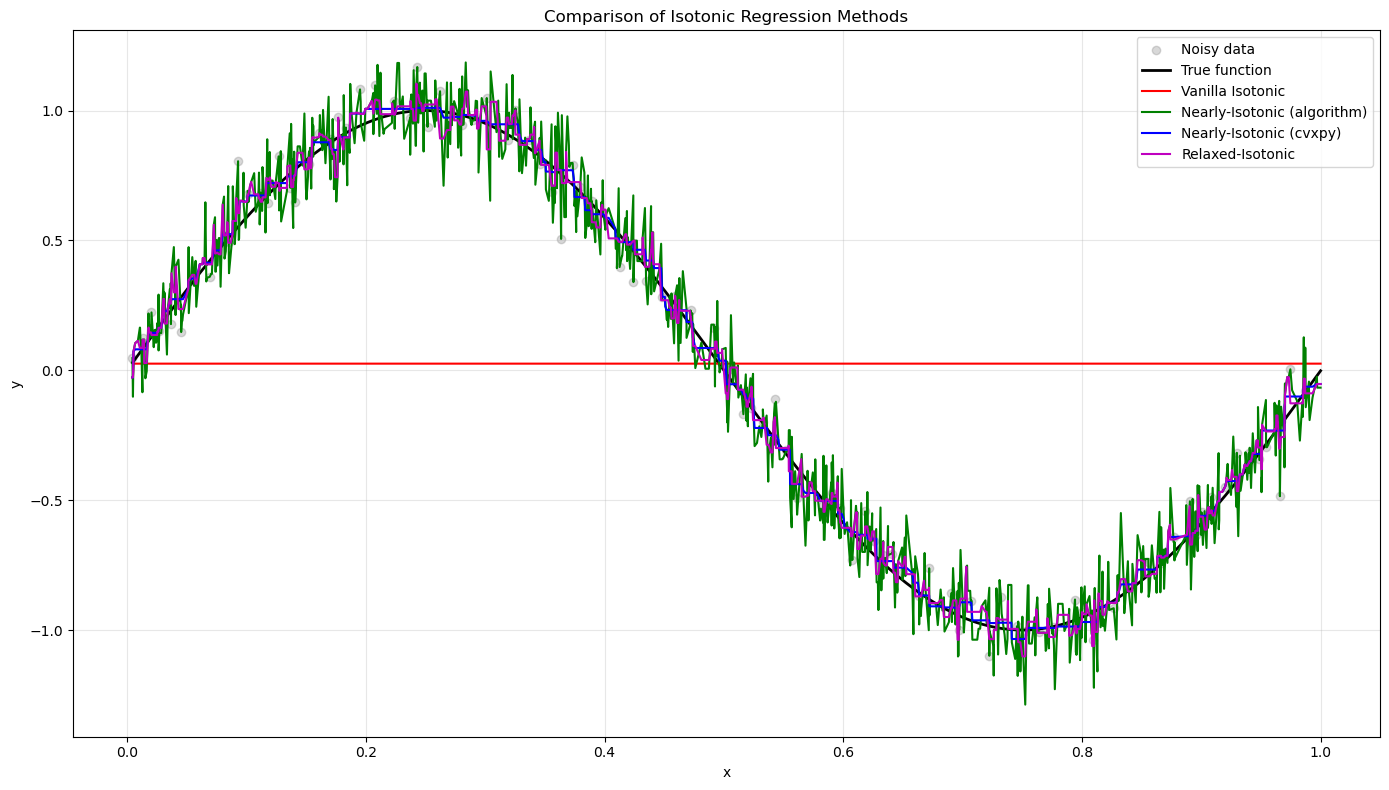

In [67]:
metrics, data = run_benchmark()

# Visualize the results (optional)
visualize_results(*data)

In [73]:
%cd /Users/soodoku/Documents/GitHub/calibre

/Users/soodoku/Documents/GitHub/calibre


In [74]:
!pip install -e .

Obtaining file:///Users/soodoku/Documents/GitHub/calibre
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for calibre (pyproject.toml) ... done
  Created wheel for calibre: filename=calibre-0.1.0-0.editable-py3-none-any.whl size=6023 sha256=ab2139db922fbe5f3e9300c59df021f7eb086ba815709586a3b7abb689fe2000
  Stored in directory: /private/var/folders/2p/6m62flgx7677h842nfsgzgvh0000gn/T/pip-ephem-wheel-cache-24rc_sk1/wheels/17/b4/1d/22c4f99d5dbbacde0c4424974deac03ff0ecbc2d2df00b893f
Successfully built calibre
  Attempting uninstall: calibre
    Found existing installation: calibre 0.1.0
    Uninstalling calibre-0.1.0:
      Successfully uninstalled calibre-0.1.0


    Noise Level                          Method  Mean Calibration Error  \
0          0.05        Nearly Isotonic (Strict)                0.025642   
1          0.05       Nearly Isotonic (Relaxed)                0.024712   
2          0.05   Nearly Isotonic Path (Strict)                0.037793   
3          0.05  Nearly Isotonic Path (Relaxed)                0.041734   
4          0.05                  I-Spline Calib                0.004772   
5          0.05                Relax PAVA (10%)                0.021854   
6          0.10        Nearly Isotonic (Strict)                0.032936   
7          0.10       Nearly Isotonic (Relaxed)                0.057510   
8          0.10   Nearly Isotonic Path (Strict)                0.077336   
9          0.10  Nearly Isotonic Path (Relaxed)                0.078911   
10         0.10                  I-Spline Calib                0.010950   
11         0.10                Relax PAVA (10%)                0.039438   
12         0.20        Ne

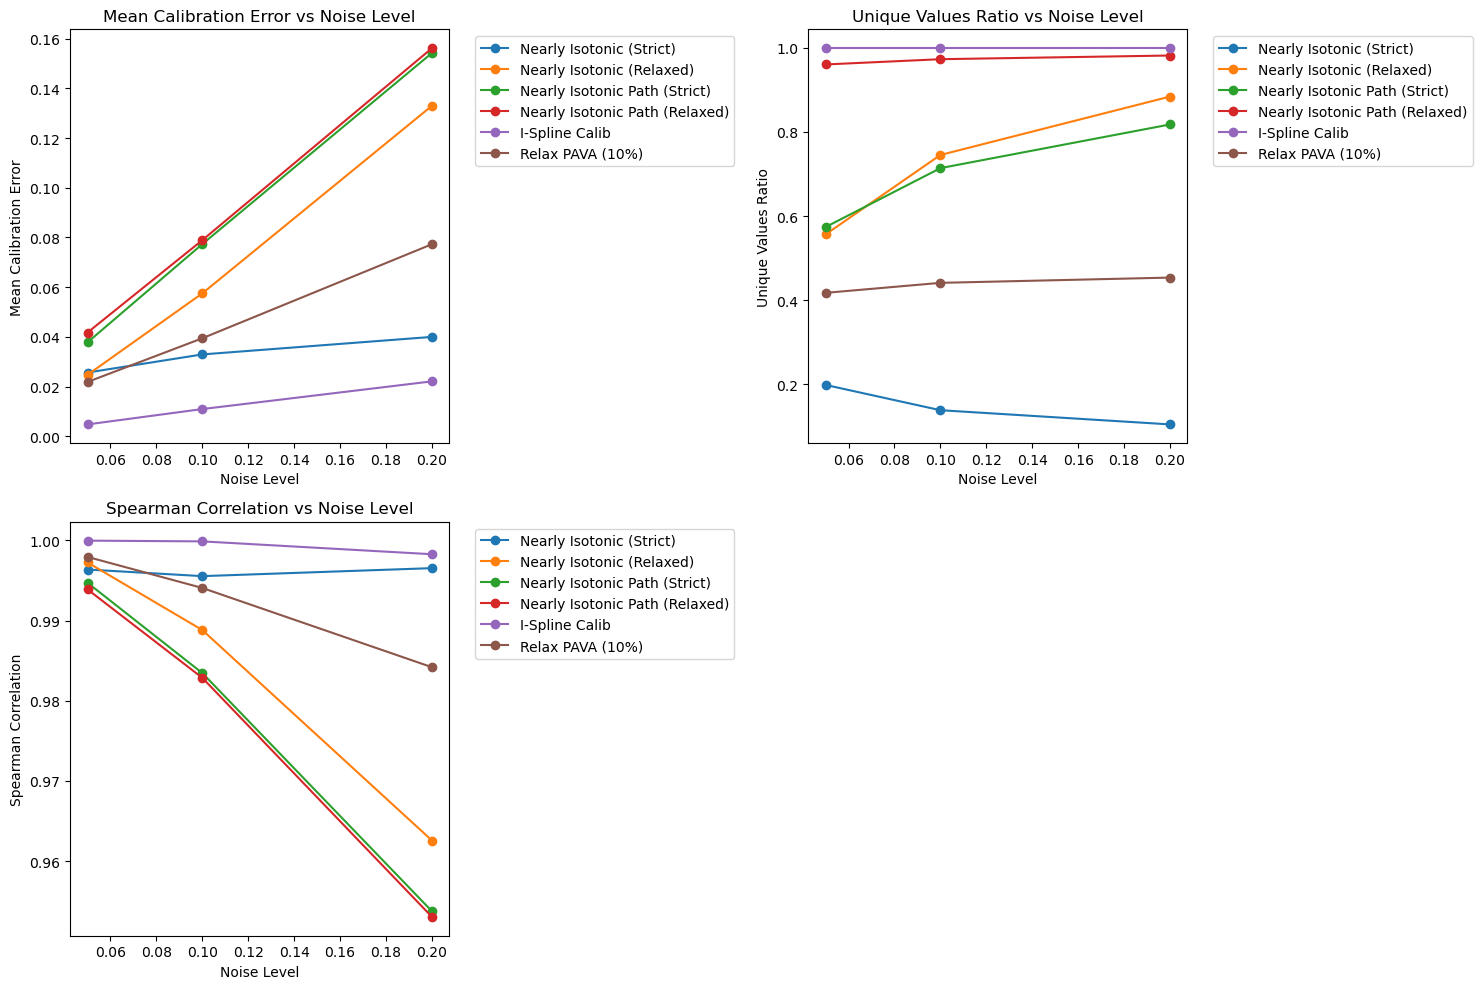

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Import calibration methods
from calibre import (
    nearly_isotonic_opt, 
    nearly_isotonic_path, 
    ispline_calib, 
    relax_pava,
    mean_calibration_error,
    binned_calibration_error,
    correlation_metrics,
    unique_value_counts
)

def generate_nonlinear_data(n_samples=1000, noise_level=0.1):
    """
    Generate synthetic data with non-linear true function and added noise.
    
    Parameters:
    -----------
    n_samples : int
        Number of samples to generate
    noise_level : float
        Standard deviation of the added Gaussian noise
    
    Returns:
    --------
    x : array
        Input features
    y_true : array
        True underlying function values
    y_noisy : array
        Noisy predictions
    """
    # Generate x values
    x = np.linspace(0, 1, n_samples)
    
    # Non-linear true function (e.g., a combination of sine and exponential)
    y_true = np.sin(2 * np.pi * x) * np.exp(x - 0.5)
    
    # Add Gaussian noise
    y_noisy = y_true + np.random.normal(0, noise_level, size=n_samples)
    
    return x, y_true, y_noisy

def benchmark_calibration_methods(noise_levels=[0.05, 0.1, 0.2]):
    """
    Benchmark different calibration methods across various noise levels.
    
    Parameters:
    -----------
    noise_levels : list
        Different noise levels to test
    
    Returns:
    --------
    results_df : pandas.DataFrame
        Comprehensive results of calibration methods
    """
    # Initialize results storage
    results = []
    
    # Iterate through different noise levels
    for noise in noise_levels:
        # Generate data
        x, y_true, y_noisy = generate_nonlinear_data(noise_level=noise)
        
        # Split data
        x_train, x_test, y_train, y_test, y_true_train, y_true_test = train_test_split(
            x, y_noisy, y_true, test_size=0.2, random_state=42
        )
        
        # Calibration methods to test
        calibration_methods = [
            ('Nearly Isotonic (Strict)', lambda x, y: nearly_isotonic_opt(x, y, lam=10.0)),
            ('Nearly Isotonic (Relaxed)', lambda x, y: nearly_isotonic_opt(x, y, lam=0.1)),
            ('Nearly Isotonic Path (Strict)', lambda x, y: nearly_isotonic_path(x, y, lam=10.0)),
            ('Nearly Isotonic Path (Relaxed)', lambda x, y: nearly_isotonic_path(x, y, lam=0.1)),
            ('I-Spline Calib', lambda x, y: ispline_calib(x, y)),
            ('Relax PAVA (10%)', lambda x, y: relax_pava(x, y, percentile=10)),
        ]
        
        # Compute metrics for each method
        for method_name, calib_func in calibration_methods:
            # Apply calibration
            y_calibrated = calib_func(x_train, y_train)
            
            # Evaluate metrics
            mce = mean_calibration_error(y_true_train, y_calibrated)
            bce = binned_calibration_error(y_true_train, y_calibrated, n_bins=10)
            corr = correlation_metrics(y_true_train, y_calibrated, x=x_train, y_orig=y_train)
            unique_counts = unique_value_counts(y_calibrated, y_orig=y_train)
            
            # Store results
            results.append({
                'Noise Level': noise,
                'Method': method_name,
                'Mean Calibration Error': mce,
                'Binned Calibration Error': bce,
                'Spearman Corr (True)': corr['spearman_corr_to_y_true'],
                'Spearman Corr (Orig)': corr.get('spearman_corr_to_y_orig', np.nan),
                'Unique Values Ratio': unique_counts['unique_value_ratio'],
                'N Unique Values': unique_counts['n_unique_y_pred'],
                'N Unique Values (Orig)': unique_counts['n_unique_y_orig']
            })
    
    # Convert to DataFrame
    results_df = pd.DataFrame(results)
    return results_df

# Run benchmark
benchmark_results = benchmark_calibration_methods()

# Display results
print(benchmark_results)

# Optional: Visualization of results
plt.figure(figsize=(15, 10))

# Plot Mean Calibration Error
plt.subplot(2, 2, 1)
for method in benchmark_results['Method'].unique():
    subset = benchmark_results[benchmark_results['Method'] == method]
    plt.plot(subset['Noise Level'], subset['Mean Calibration Error'], 
             marker='o', label=method)
plt.title('Mean Calibration Error vs Noise Level')
plt.xlabel('Noise Level')
plt.ylabel('Mean Calibration Error')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot Unique Values Ratio
plt.subplot(2, 2, 2)
for method in benchmark_results['Method'].unique():
    subset = benchmark_results[benchmark_results['Method'] == method]
    plt.plot(subset['Noise Level'], subset['Unique Values Ratio'], 
             marker='o', label=method)
plt.title('Unique Values Ratio vs Noise Level')
plt.xlabel('Noise Level')
plt.ylabel('Unique Values Ratio')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot Spearman Correlation
plt.subplot(2, 2, 3)
for method in benchmark_results['Method'].unique():
    subset = benchmark_results[benchmark_results['Method'] == method]
    plt.plot(subset['Noise Level'], subset['Spearman Corr (True)'], 
             marker='o', label=method)
plt.title('Spearman Correlation vs Noise Level')
plt.xlabel('Noise Level')
plt.ylabel('Spearman Correlation')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()
